# House Prices: Advanced Regression Techniques


## Import thư viện & Load dữ liệu

In [18]:
# ==============================================================
# PHẦN 1: IMPORT THƯ VIỆN & LOAD DỮ LIỆU
# ==============================================================
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

# Đường dẫn Kaggle hoặc local
TRAIN_PATH = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv'
TEST_PATH  = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv'

train = pd.read_csv(TRAIN_PATH if os.path.exists(TRAIN_PATH) else 'train.csv')
test  = pd.read_csv(TEST_PATH  if os.path.exists(TEST_PATH)  else 'test.csv')

print(f'Kích thước ban đầu - Train: {train.shape}, Test: {test.shape}')

# Lưu Id để tạo submission
test_id = test['Id'].copy()

Kích thước ban đầu - Train: (1460, 81), Test: (1459, 80)


## EDA – Khám phá dữ liệu & Outliers

### 2.1. Phân phối biến mục tiêu `SalePrice`

Quan sát quan trọng: `SalePrice` có phân phối lệch phải mạnh (right-skewed). Vì metric của Kaggle là RMSLE (RMSE trên log), ta nên log-transform target trước khi train.

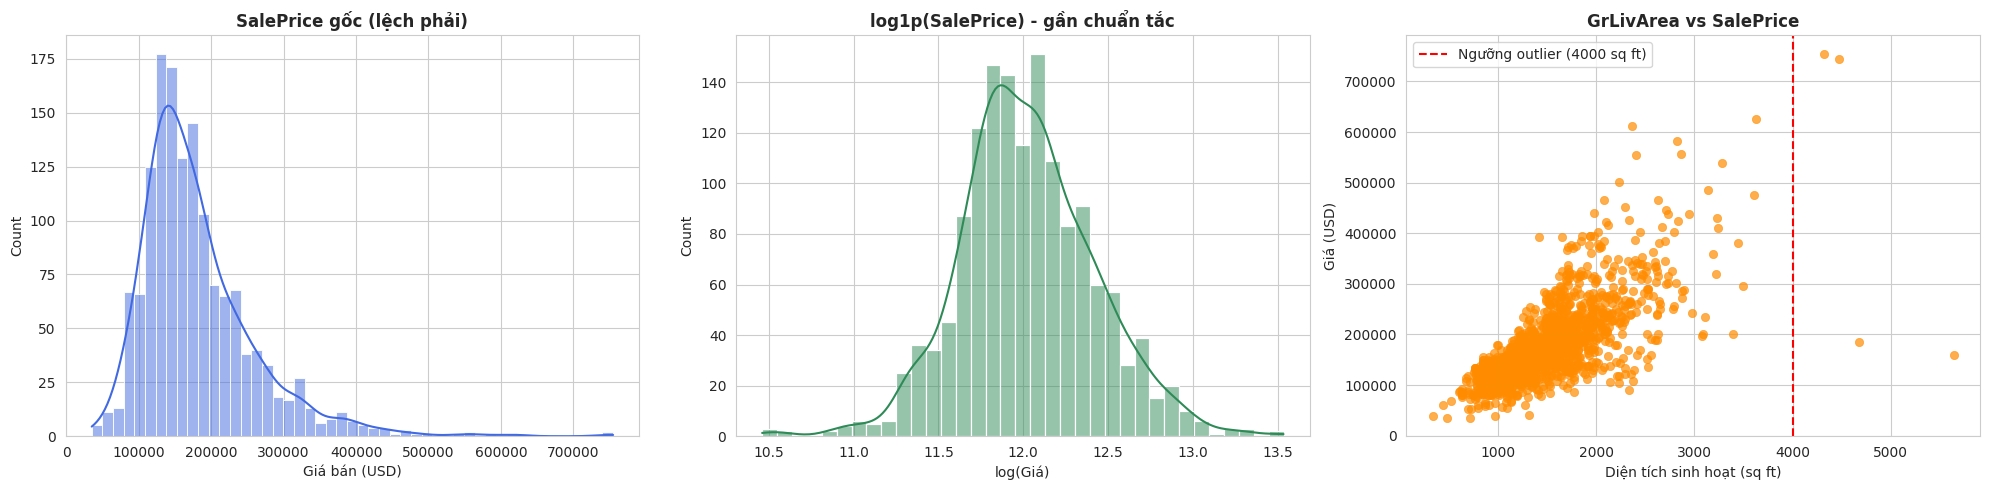

Số lượng outliers (GrLivArea > 4000): 4
        Id  GrLivArea  SalePrice
523    524       4676     184750
691    692       4316     755000
1182  1183       4476     745000
1298  1299       5642     160000


In [19]:
# ==============================================================
# PHẦN 2: EDA
# ==============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 2.1 - Phân phối SalePrice (gốc vs log)
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('SalePrice gốc (lệch phải)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá bán (USD)')

sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('log1p(SalePrice) - gần chuẩn tắc', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Giá)')

# 2.2 - Outliers theo GrLivArea > 4000
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'],
                ax=axes[2], color='darkorange', alpha=0.7, edgecolor=None)
axes[2].axvline(4000, color='red', linestyle='--', label='Ngưỡng outlier (4000 sq ft)')
axes[2].set_title('GrLivArea vs SalePrice', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Diện tích sinh hoạt (sq ft)')
axes[2].set_ylabel('Giá (USD)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Đếm outliers
outliers = train[train['GrLivArea'] > 4000]
print(f'Số lượng outliers (GrLivArea > 4000): {len(outliers)}')
print(outliers[['Id', 'GrLivArea', 'SalePrice']])

## Tiền xử lý dữ liệu

### 3.1. Loại bỏ outliers

Theo gợi ý của tác giả Dean De Cock, các căn nhà có GrLivArea > 4000 nhưng giá thấp bất thường nên được loại bỏ khỏi tập train.

In [20]:
# Loại bỏ outliers
print(f'Trước khi xóa: {train.shape}')
train = train[train['GrLivArea'] <= 4000].reset_index(drop=True)
print(f'Sau khi xóa:   {train.shape}')

Trước khi xóa: (1460, 81)
Sau khi xóa:   (1456, 81)


### 3.2. Xử lý Missing Values

Chiến lược:
- **Drop** các cột có > 70% missing: `Alley`, `PoolQC`, `Fence`, `MiscFeature`, `Id`
- **Categorical** → fill bằng `mode`
- **Numerical** → fill bằng `mean`

In [21]:
# ----------------------------------------------------------
# 3.2. Xử lý missing values
# ----------------------------------------------------------
cat_col_train = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'GarageQual', 'GarageCond'
]
ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for col in cat_col_train:
    if col in train.columns:
        train[col] = train[col].fillna(train[col].mode()[0])

for col in ncat_col_train:
    if col in train.columns:
        train[col] = train[col].fillna(train[col].mean())

cat_col_test = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'GarageQual', 'GarageCond', 'MSZoning',
    'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual',
    'Functional', 'SaleType'
]
ncat_col_test = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1',
    'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
    'BsmtHalfBath', 'GarageCars', 'GarageArea'
]

for col in cat_col_test:
    if col in test.columns:
        test[col] = test[col].fillna(test[col].mode()[0])

for col in ncat_col_test:
    if col in test.columns:
        test[col] = test[col].fillna(test[col].mean())

# Drop các cột thiếu nhiều
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
train.drop(columns=to_drop, inplace=True, errors='ignore')
test.drop(columns=to_drop,  inplace=True, errors='ignore')

print(f'Sau khi xử lý missing - Train: {train.shape}, Test: {test.shape}')

Sau khi xử lý missing - Train: (1456, 76), Test: (1459, 75)


### 3.3. Feature Engineering

Tạo các feature mới mang ý nghĩa thực tế:

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` | Tổng diện tích |
| `TotalBath` | `FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath` | Tổng số phòng tắm (quy đổi) |
| `TotalPorch` | `OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch` | Tổng diện tích hiên |
| `Age` | `YrSold - YearBuilt` | Tuổi nhà khi bán |
| `RemodAge` | `YrSold - YearRemodAdd` | Tuổi lần sửa gần nhất |
| `IsRemodeled` | `YearRemodAdd != YearBuilt` | Đã từng sửa chưa |
| `HasPool` | `PoolArea > 0` | Có hồ bơi |
| `HasGarage` | `GarageArea > 0` | Có garage |
| `HasFireplace` | `Fireplaces > 0` | Có lò sưởi |

In [22]:
# ----------------------------------------------------------
# 3.3. Feature Engineering
# ----------------------------------------------------------
def add_features(df):
    df = df.copy()
    df['TotalSF']    = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath']  = (df['FullBath'] + 0.5*df['HalfBath']
                        + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
    df['TotalPorch'] = (df['OpenPorchSF'] + df['EnclosedPorch']
                        + df['3SsnPorch'] + df['ScreenPorch'])
    df['Age']        = df['YrSold'] - df['YearBuilt']
    df['RemodAge']   = df['YrSold'] - df['YearRemodAdd']
    df['IsRemodeled']= (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['HasPool']    = (df['PoolArea'] > 0).astype(int)
    df['HasGarage']  = (df['GarageArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    return df

train = add_features(train)
test  = add_features(test)

# Log-transform target
y_train_log = np.log1p(train['SalePrice'])

print(f'Đã tạo thêm 9 features mới. Train: {train.shape}, Test: {test.shape}')

Đã tạo thêm 9 features mới. Train: (1456, 85), Test: (1459, 84)


### 3.4. One-Hot Encoding

Gộp train + test để các category được encode giống nhau (tránh lệch category giữa 2 tập).

In [23]:
# ----------------------------------------------------------
# 3.4. Gộp & One-Hot Encoding
# ----------------------------------------------------------
n_train = train.shape[0]
y_train = train['SalePrice'].reset_index(drop=True)

all_df = pd.concat([
    train.drop(['SalePrice'], axis=1),
    test
], axis=0).reset_index(drop=True)

all_cat_col = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
    'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
    'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual',
    'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
    'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
    'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType',
    'SaleCondition'
]

all_df = pd.get_dummies(all_df, columns=[c for c in all_cat_col if c in all_df.columns], drop_first=True)
all_df = all_df.loc[:, ~all_df.columns.duplicated()]

X_train = all_df.iloc[:n_train].astype(float)
X_test  = all_df.iloc[n_train:].astype(float)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

# Kiểm tra không còn NaN
assert X_train.isna().sum().sum() == 0, 'Còn NaN trong X_train!'
assert X_test.isna().sum().sum()  == 0, 'Còn NaN trong X_test!'
print('✅ Không còn NaN')

X_train: (1456, 243), X_test: (1459, 243)
✅ Không còn NaN


## Huấn luyện 5 mô hình

### Hàm đánh giá

Vì metric của Kaggle là **RMSLE**, ta sẽ:
- Train trên `log1p(SalePrice)`
- Dự đoán → chuyển về giá gốc bằng `expm1`
- Tính RMSLE trên log của giá gốc

Với cách này, mọi mô hình đều tối ưu trực tiếp metric của cuộc thi.

In [24]:
# ==============================================================
# PHẦN 4: HÀM ĐÁNH GIÁ
# ==============================================================
def rmsle(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 1, None)
    return np.sqrt(mean_squared_error(np.log(y_true), np.log(y_pred)))

def evaluate_model(name, model, X_tr, y_tr_log, X_te):
    """
    - Fit model trên log(SalePrice)
    - Dự đoán train (để kiểm tra overfit)
    - Dự đoán test (để tạo submission)
    - Tính RMSLE trên tập train
    """
    model.fit(X_tr, y_tr_log)

    # Dự đoán train
    pred_log_train = model.predict(X_tr)
    pred_train     = np.expm1(pred_log_train)
    rmsle_train    = rmsle(y_train, pred_train)

    # Dự đoán test
    pred_test_log = model.predict(X_te)
    pred_test     = np.expm1(pred_test_log)

    print(f'   ➜ RMSLE train [{name}]: {rmsle_train:.5f}')

    return {
        'name': name,
        'model': model,
        'rmsle_train': rmsle_train,
        'pred_test': pred_test
    }

results = []

### 4.1. Decision Tree Regressor

Mô hình cơ sở, dễ overfit nhưng nhanh và dễ diễn giải.

In [25]:
print('=' * 60)
print('MÔ HÌNH 1: DECISION TREE')
print('=' * 60)

dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
res = evaluate_model('Decision Tree', dt, X_train, y_train_log, X_test)
results.append(res)

MÔ HÌNH 1: DECISION TREE
   ➜ RMSLE train [Decision Tree]: 0.10581


### 4.2. Random Forest Regressor

Ensemble của nhiều decision tree, ít overfit hơn hẳn.

In [26]:
print('=' * 60)
print('MÔ HÌNH 2: RANDOM FOREST')
print('=' * 60)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
res = evaluate_model('Random Forest', rf, X_train, y_train_log, X_test)
results.append(res)

MÔ HÌNH 2: RANDOM FOREST
   ➜ RMSLE train [Random Forest]: 0.06243


### 4.3. XGBoost với RandomizedSearchCV

Dùng `tree_method='hist'` (nhanh hơn `exact` 5-10 lần), `n_iter` vừa phải, `cv=3` để tránh chạy quá lâu.

In [27]:
print('=' * 60)
print('MÔ HÌNH 3: XGBOOST (tuned)')
print('=' * 60)

xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=1
)

param_xgb = {
    'n_estimators':     [300, 600, 900],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb_base, param_xgb,
    n_iter=15, cv=3,
    scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train_log)
print(f'   Best params: {xgb_search.best_params_}')

best_xgb = xgb_search.best_estimator_
res = evaluate_model('XGBoost', best_xgb, X_train, y_train_log, X_test)
results.append(res)

MÔ HÌNH 3: XGBOOST (tuned)
Fitting 3 folds for each of 15 candidates, totalling 45 fits
   Best params: {'subsample': 1.0, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
   ➜ RMSLE train [XGBoost]: 0.07204


### 4.4. LightGBM

Nhanh hơn XGBoost đáng kể, thường cho kết quả tương đương hoặc tốt hơn.

In [28]:
print('=' * 60)
print('MÔ HÌNH 4: LIGHTGBM')
print('=' * 60)

lgb_model = lgb.LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
res = evaluate_model('LightGBM', lgb_model, X_train, y_train_log, X_test)
results.append(res)

MÔ HÌNH 4: LIGHTGBM
   ➜ RMSLE train [LightGBM]: 0.01488


### 4.5. Artificial Neural Network (Keras)

Mạng neural với 3 lớp ẩn, huấn luyện trên log(SalePrice), dùng early stopping để tránh overfit.

In [29]:
# ==============================================================================
# PHẦN 4.5: NEURAL NETWORK (Keras) — ĐÃ SỬA
# ==============================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from sklearn.preprocessing import StandardScaler

print('=' * 60)
print('MÔ HÌNH 5: NEURAL NETWORK (Keras)')
print('=' * 60)

# ---- 1. SCALE FEATURES ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit trên train
X_test_scaled  = scaler.transform(X_test)        # transform test (KHÔNG fit lại)

print(f'   ➜ Đã scale features: mean ≈ 0, std ≈ 1')

# ---- 2. Định nghĩa RMSE loss ----
def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

tf.random.set_seed(42)

# ---- 3. Kiến trúc mạng ----
nn_model = Sequential([
    Dense(128, kernel_initializer='he_uniform', activation='relu',
          input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, kernel_initializer='he_uniform', activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, kernel_initializer='he_uniform', activation='relu'),
    Dense(1, kernel_initializer='he_uniform')
])

nn_model.compile(
    loss=rmse,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

# ---- 4. Callbacks ----
callbacks = [
    EarlyStopping(patience=30, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-5, monitor='val_loss')
]

# ---- 5. Huấn luyện (DÙNG SCALED DATA) ----
history = nn_model.fit(
    X_train_scaled, y_train_log.values,      # ← đã scale
    validation_split=0.2,
    batch_size=32,
    epochs=300,
    verbose=0,
    callbacks=callbacks
)

# ---- 6. Dự đoán (DÙNG SCALED DATA) ----
pred_train_nn = np.expm1(nn_model.predict(X_train_scaled, verbose=0).flatten())
pred_test_nn  = np.expm1(nn_model.predict(X_test_scaled,  verbose=0).flatten())

rmsle_nn = rmsle(y_train, pred_train_nn)
print(f'   ➜ Số epoch đã train: {len(history.history["loss"])}')
print(f'   ➜ RMSLE train [Neural Network]: {rmsle_nn:.5f}')

results.append({
    'name':        'Neural Network',
    'model':       nn_model,
    'rmsle_train': rmsle_nn,
    'pred_test':   pred_test_nn
})

nn_model.save('nn_model.keras')

MÔ HÌNH 5: NEURAL NETWORK (Keras)
   ➜ Đã scale features: mean ≈ 0, std ≈ 1
   ➜ Số epoch đã train: 49
   ➜ RMSLE train [Neural Network]: 0.62417


## 5️⃣ Đánh giá & Chọn mô hình tốt nhất


📊 BẢNG SO SÁNH CÁC MÔ HÌNH
         Model  RMSLE (train)
      LightGBM        0.01488
 Random Forest        0.06243
       XGBoost        0.07204
 Decision Tree        0.10581
Neural Network        0.62417


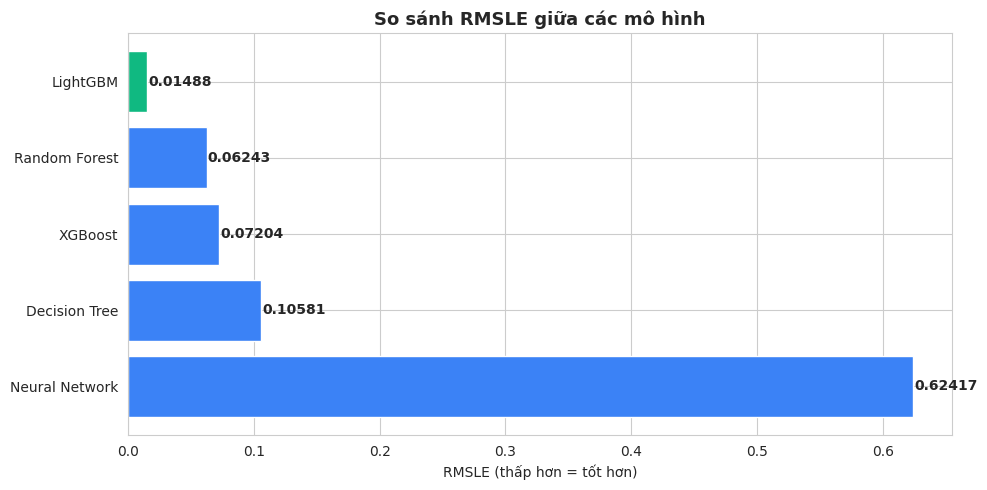


🏆 Mô hình tốt nhất trên tập train: LightGBM


In [30]:
# ==============================================================
# PHẦN 5: SO SÁNH KẾT QUẢ
# ==============================================================
summary = pd.DataFrame([
    {'Model': r['name'], 'RMSLE (train)': round(r['rmsle_train'], 5)}
    for r in results
]).sort_values('RMSLE (train)').reset_index(drop=True)

print('\n📊 BẢNG SO SÁNH CÁC MÔ HÌNH')
print('=' * 45)
print(summary.to_string(index=False))

# Biểu đồ
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#10b981' if i == 0 else '#3b82f6' for i in range(len(summary))]
bars = ax.barh(summary['Model'], summary['RMSLE (train)'], color=colors)
ax.set_xlabel('RMSLE (thấp hơn = tốt hơn)')
ax.set_title('So sánh RMSLE giữa các mô hình', fontweight='bold', fontsize=13)
ax.invert_yaxis()

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.001, bar.get_y() + bar.get_height()/2,
            f'{w:.5f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

best_model_name = summary.iloc[0]['Model']
print(f'\n🏆 Mô hình tốt nhất trên tập train: {best_model_name}')

### 5.1. Blending (Ensemble)

Kết hợp dự đoán của các mô hình mạnh (XGBoost + LightGBM + Random Forest) để tăng độ ổn định.

In [31]:
# ----------------------------------------------------------
# 5.1. Ensemble: trung bình cộng (weighted)
# ----------------------------------------------------------
weights = {
    'XGBoost':       0.35,
    'LightGBM':      0.40,
    'Random Forest': 0.15,
    'Neural Network':0.10,
}

blend_pred = np.zeros(len(X_test))
total_w = 0

for r in results:
    w = weights.get(r['name'], 0)
    if w > 0:
        blend_pred += w * r['pred_test']
        total_w += w

blend_pred /= total_w
print(f'✅ Đã tạo blend prediction từ {total_w:.2f} tổng trọng số')
print(f'   Min: {blend_pred.min():,.0f} | Max: {blend_pred.max():,.0f} | Mean: {blend_pred.mean():,.0f}')

✅ Đã tạo blend prediction từ 1.00 tổng trọng số
   Min: 48,546 | Max: 16,211,540 | Mean: 198,122


## Feature Importance

Trực quan hóa 20 feature quan trọng nhất theo mô hình LightGBM (nhanh, gain-based).

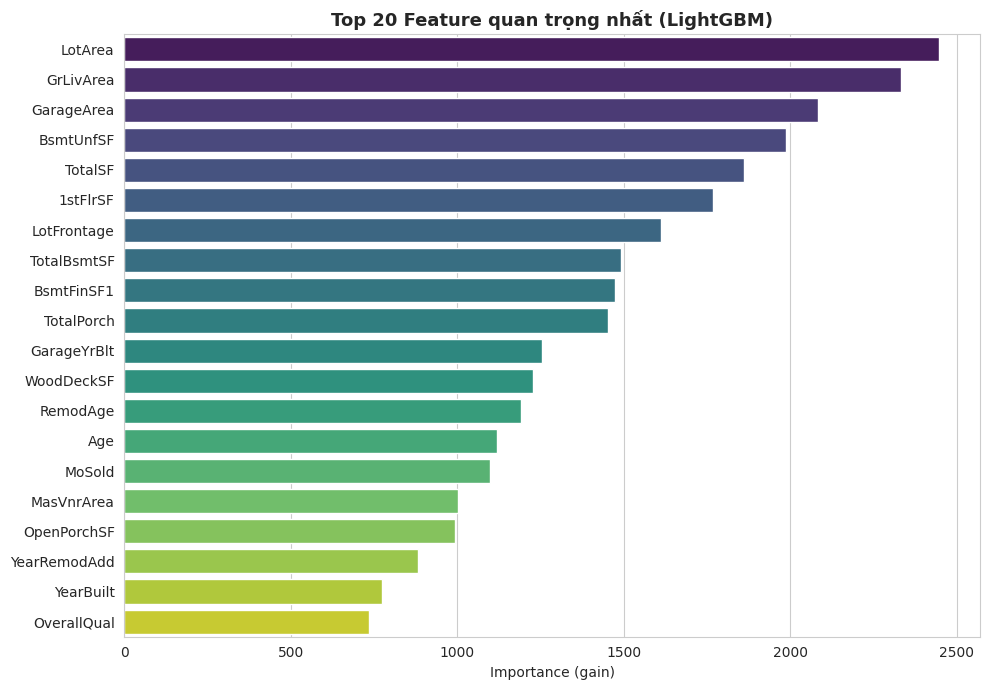

In [32]:
# ==============================================================
# PHẦN 6: FEATURE IMPORTANCE
# ==============================================================
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importance, x='importance', y='feature',
            palette='viridis', ax=ax)
ax.set_title('Top 20 Feature quan trọng nhất (LightGBM)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance (gain)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Tạo file Submission

Sinh 6 file submission:
- 5 file cho từng mô hình riêng
- 1 file `sample_sub_blend.csv` cho ensemble

In [33]:
# ==============================================================
# PHẦN 7: SUBMISSION
# ==============================================================
SUB_DIR = 'submissions'
os.makedirs(SUB_DIR, exist_ok=True)

# 1. Từng mô hình riêng
short_names = {
    'Decision Tree':   'dt',
    'Random Forest':   'rf',
    'XGBoost':         'xgb',
    'LightGBM':        'lgb',
    'Neural Network':  'nn',
}

for r in results:
    sub = pd.DataFrame({'Id': test_id, 'SalePrice': r['pred_test']})
    path = f"{SUB_DIR}/sub_{short_names[r['name']]}.csv"
    sub.to_csv(path, index=False)
    print(f'✅ Đã ghi: {path}')

# 2. Blend
sub_blend = pd.DataFrame({'Id': test_id, 'SalePrice': blend_pred})
sub_blend.to_csv(f'{SUB_DIR}/sub_blend.csv', index=False)
print(f'✅ Đã ghi: {SUB_DIR}/sub_blend.csv')

# 3. Preview
print('\n📄 Preview submission blend:')
print(sub_blend.head())
print(f'\nTổng số dòng: {len(sub_blend)} (kỳ vọng: 1459)')

✅ Đã ghi: submissions/sub_dt.csv
✅ Đã ghi: submissions/sub_rf.csv
✅ Đã ghi: submissions/sub_xgb.csv
✅ Đã ghi: submissions/sub_lgb.csv
✅ Đã ghi: submissions/sub_nn.csv
✅ Đã ghi: submissions/sub_blend.csv

📄 Preview submission blend:
     Id      SalePrice
0  1461  121041.021408
1  1462  156729.642387
2  1463  183393.430844
3  1464  185747.709341
4  1465  181699.526749

Tổng số dòng: 1459 (kỳ vọng: 1459)
